In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_month'] = df['job_posted_date'].dt.strftime('%b')


In [ ]:
def manipulator(x):
    return ast.literal_eval(x)

df = df.dropna(subset=['job_skills'])

df['job_skills'] = df['job_skills'].apply(manipulator)
df = df.explode('job_skills')

df = df[df['job_country'] == 'United States']


In [24]:
top_three_jobs = list(df.job_title_short.value_counts().head(3).index)

df_job1 = df[df.job_title_short == top_three_jobs[0]]
print(top_three_jobs[0])

job1 = df_job1.groupby('job_skills').agg(count = ('job_skills' , 'count'))
job1 = job1.sort_values('count', ascending = False).head(5)
job1.sort_values(by = 'count', ascending=True, inplace=True)
job1


Data Scientist


,count
job_skills,
tableau,13859
sas,14340
r,26022
sql,30034
python,42379


In [25]:
df_job2 = df[df.job_title_short == top_three_jobs[1]]
print(top_three_jobs[1])

job2 = df_job2.groupby('job_skills').agg(count = ('job_skills' , 'count'))
job2 = job2.sort_values('count', ascending = False).head(5)
job2.sort_values(by = 'count', ascending=True, inplace=True)
job2

Data Engineer


,count
job_skills,
spark,11242
azure,11321
aws,15018
python,22762
sql,23958


In [26]:
df_job3 = df[df.job_title_short == top_three_jobs[2]]
print(top_three_jobs[2])

job3 = df_job3.groupby('job_skills').agg(count = ('job_skills' , 'count'))
job3 = job3.sort_values('count', ascending = False).head(5)
job3.sort_values(by = 'count', ascending=True, inplace=True)
job3

Data Analyst


,count
job_skills,
sas,13200
python,18382
tableau,19311
excel,27519
sql,34452


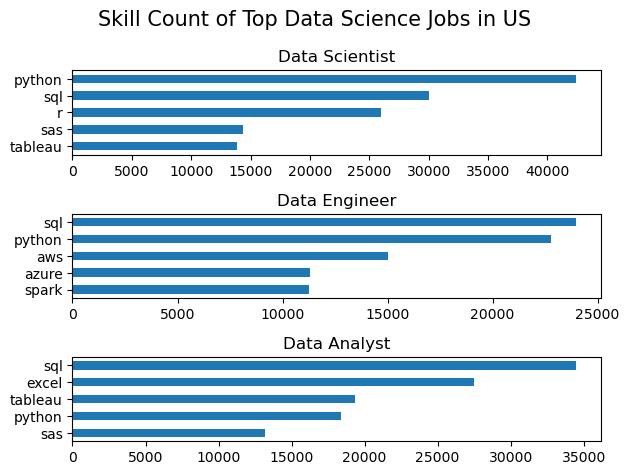

In [41]:
fig , ax = plt.subplots(3,1)

job1.plot(kind = 'barh' , ax = ax[0])
job2.plot(kind = 'barh' , ax = ax[1])
job3.plot(kind = 'barh' , ax = ax[2])
ax[0].set_ylabel("")
ax[1].set_ylabel("")
ax[2].set_ylabel("")
fig.suptitle('Skill Count of Top Data Science Jobs in US',fontsize = 15)
ax[0].legend().set_visible(False)
ax[1].legend().set_visible(False)
ax[2].legend().set_visible(False)
ax[0].set_title('Data Scientist')
ax[1].set_title('Data Engineer')
ax[2].set_title('Data Analyst')
fig.tight_layout()

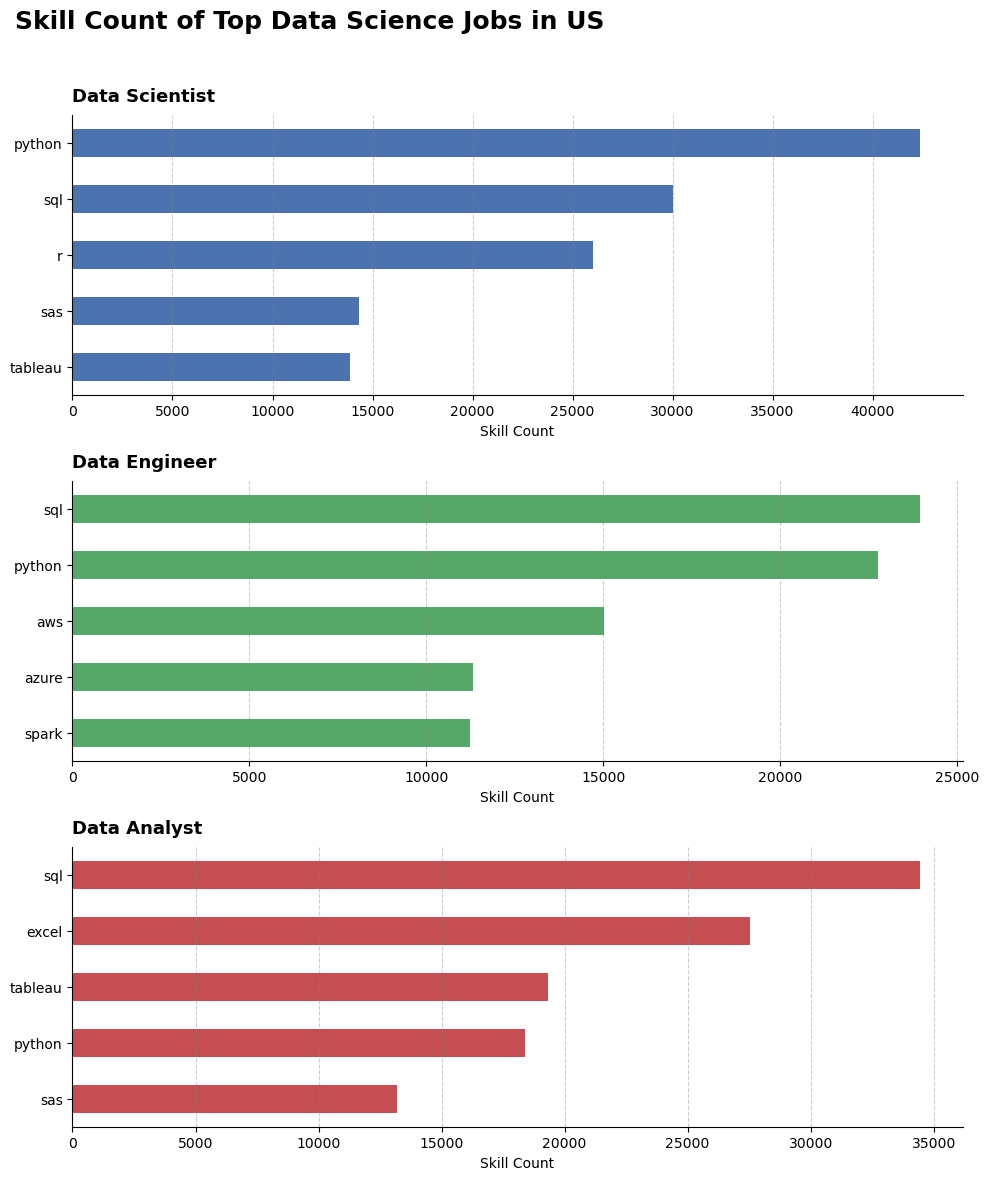

In [43]:
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(3, 1, figsize=(10, 12))

job1.plot(kind='barh', ax=ax[0], color=colors[0], legend=False)
job2.plot(kind='barh', ax=ax[1], color=colors[1], legend=False)
job3.plot(kind='barh', ax=ax[2], color=colors[2], legend=False)

titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

for i, a in enumerate(ax):
    a.set_ylabel("")
    a.set_xlabel("Skill Count", fontsize=10)
    a.set_title(titles[i], fontsize=13, fontweight='bold', loc='left', pad=10)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.grid(axis='x', linestyle='--', alpha=0.4, color='gray')
    a.tick_params(axis='y', labelsize=10)

fig.suptitle('Skill Count of Top Data Science Jobs in US', fontsize=18, fontweight='bold', x=0.02, ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

C:\Users\skuma\AppData\Local\Temp\ipykernel_6120\4168305182.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmaps[i])


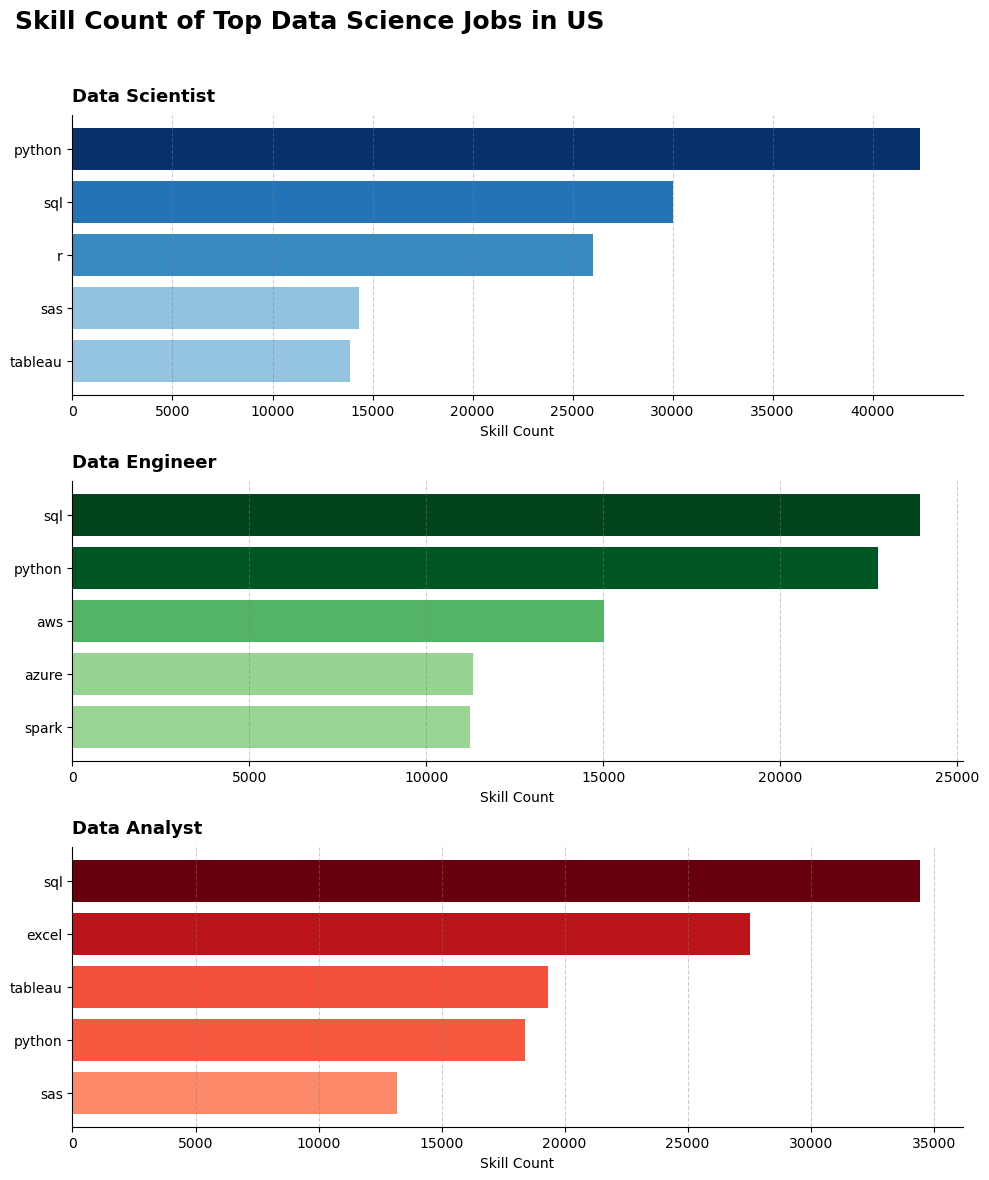

In [45]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

fig, ax = plt.subplots(3, 1, figsize=(10, 12))

jobs = [job1, job2, job3]
titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']
cmaps = ['Blues', 'Greens', 'Reds']

for i, a in enumerate(ax):
    data = jobs[i].iloc[:, 0]
    norm = mcolors.Normalize(vmin=data.min(), vmax=data.max())
    cmap = cm.get_cmap(cmaps[i])
    bar_colors = [cmap(0.4 + 0.6 * norm(val)) for val in data]

    a.barh(data.index, data.values, color=bar_colors)
    a.set_ylabel("")
    a.set_xlabel("Skill Count", fontsize=10)
    a.set_title(titles[i], fontsize=13, fontweight='bold', loc='left', pad=10)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.grid(axis='x', linestyle='--', alpha=0.4, color='gray')
    a.tick_params(axis='y', labelsize=10)

fig.suptitle('Skill Count of Top Data Science Jobs in US', fontsize=18, fontweight='bold', x=0.02, ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()